In [219]:
import numpy as np
import pandas as pd

In [220]:
df = pd.read_csv('spam.csv',encoding='latin-1')

In [221]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3803,ham,"No dude, its not fake..my frnds got money, tht...",NaN,NaN,NaN
3429,ham,You've always been the brainy one.,NaN,NaN,NaN
4582,spam,For ur chance to win a å£250 wkly shopping spr...,NaN,NaN,NaN
2470,ham,Eat at old airport road... But now 630 oredi.....,NaN,NaN,NaN
3461,spam,Bloomberg -Message center +447797706009 Why wa...,NaN,NaN,NaN


#1 Data cleaning

In [222]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [223]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [224]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [225]:
#renaming
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
445,ham,"Sorry, my battery died, I can come by but I'm ..."
1310,ham,"I.ll always be there, even if its just in spir..."
953,ham,Also remember to get dobby's bowl from your car
1637,spam,"0A$NETWORKS allow companies to bill for SMS, s..."
1045,ham,"Come round, it's ."


In [226]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [227]:
df['target'] = encoder.fit_transform(df['target'])

In [228]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [229]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [230]:
#duplicate
df.duplicated().sum()

np.int64(403)

In [231]:
#remove duplicate
df = df.drop_duplicates(keep='first')

In [232]:
df.duplicated().sum()

np.int64(0)

In [233]:
df.shape

(5169, 2)

2.EDA

In [234]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

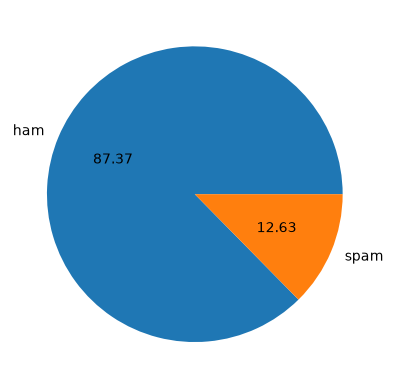

In [235]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

# Data imbalnce 

In [236]:
!pip install nltk
import nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\rocky\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [237]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rocky\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [238]:
df['num_chracters'] = df['text'].apply(len)

In [239]:
df.head()

,target,text,num_chracters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
